# Macro Regime Trader - Live Demo

This notebook is a live, end-to-end walkthrough of the `macro_regime_trader` engine: it detects macro market regimes from price/volume structure, adapts strategy exposure to the detected regime, and simulates the resulting portfolio against simple benchmarks.

All data below is **real historical market data** fetched live via `yfinance`. This notebook is a research and education tool - a paper-trading simulation with no broker connectivity or API keys involved. **Nothing here is investment advice.**

## 1. Fetch real market data

We use `YFinanceProvider` to pull daily OHLCV bars for **SPY** (a highly liquid S&P 500 ETF) starting from 2015-01-01. The provider transparently caches results to a local parquet file, so re-running this cell after the first time will not hit the network again.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from macro_regime_trader.backtest.analytics import compute_metrics
from macro_regime_trader.backtest.benchmarks import buy_and_hold_equity, dma_crossover_equity
from macro_regime_trader.backtest.engine import run_backtest, run_walk_forward_backtest
from macro_regime_trader.config import get_settings
from macro_regime_trader.core.macro_engine import MacroRegimeEngine
from macro_regime_trader.data.yfinance_provider import YFinanceProvider

TICKER = "SPY"
START = "2015-01-01"

settings = get_settings()
provider = YFinanceProvider()
ohlcv = provider.get_ohlcv(TICKER, start=START)

print(f"Fetched {len(ohlcv)} bars for {TICKER} from {ohlcv.index[0].date()} to {ohlcv.index[-1].date()}")
ohlcv.head()

Fetched 2898 bars for SPY from 2015-01-02 to 2026-07-14


,open,high,low,close,volume
date,,,,,
2015-01-02,170.472558,170.885565,168.655319,169.687836,121465900.0
2015-01-05,168.647066,168.812266,166.317716,166.623337,169632600.0
2015-01-06,166.928934,167.449326,164.260916,165.053894,209151400.0
2015-01-07,166.375475,167.449294,165.929434,167.110626,125346700.0
2015-01-08,168.514916,170.290852,168.498405,170.076080,147217800.0


In [2]:
ohlcv.tail()

,open,high,low,close,volume
date,,,,,
2026-07-08,743.159973,746.150024,739.510010,745.400024,43767400.0
2026-07-09,747.349976,751.969971,745.590027,751.710022,41441700.0
2026-07-10,752.049988,755.419983,748.099976,754.950012,42191300.0
2026-07-13,752.469971,753.909973,748.000000,749.169983,44013600.0
2026-07-14,750.909973,753.299988,748.659973,751.830017,35135286.0


## 2. Detect macro regimes

`MacroRegimeEngine.classify` labels every bar with one of four regimes based on an EMA momentum crossover and rolling volume participation: `sustained_bull`, `structural_bear`, `volatile_distribution`, and `compressed_liquidity`. Rows in the initial warmup window (before the slower EMA has enough history) are left as `None`.

We also call `classify_latest` to see what regime the engine believes we are in *right now*, and visualize the full regime history shaded behind the close price.

In [3]:
engine = MacroRegimeEngine(settings)
regimes = engine.classify(ohlcv)
latest_regime = engine.classify_latest(ohlcv)

print(f"Most recent detected regime for {TICKER}: {latest_regime.value}")
regimes.value_counts(dropna=False)

Most recent detected regime for SPY: volatile_distribution


volatile_distribution    1690
compressed_liquidity      534
sustained_bull            514
structural_bear           110
None                       50
Name: count, dtype: int64

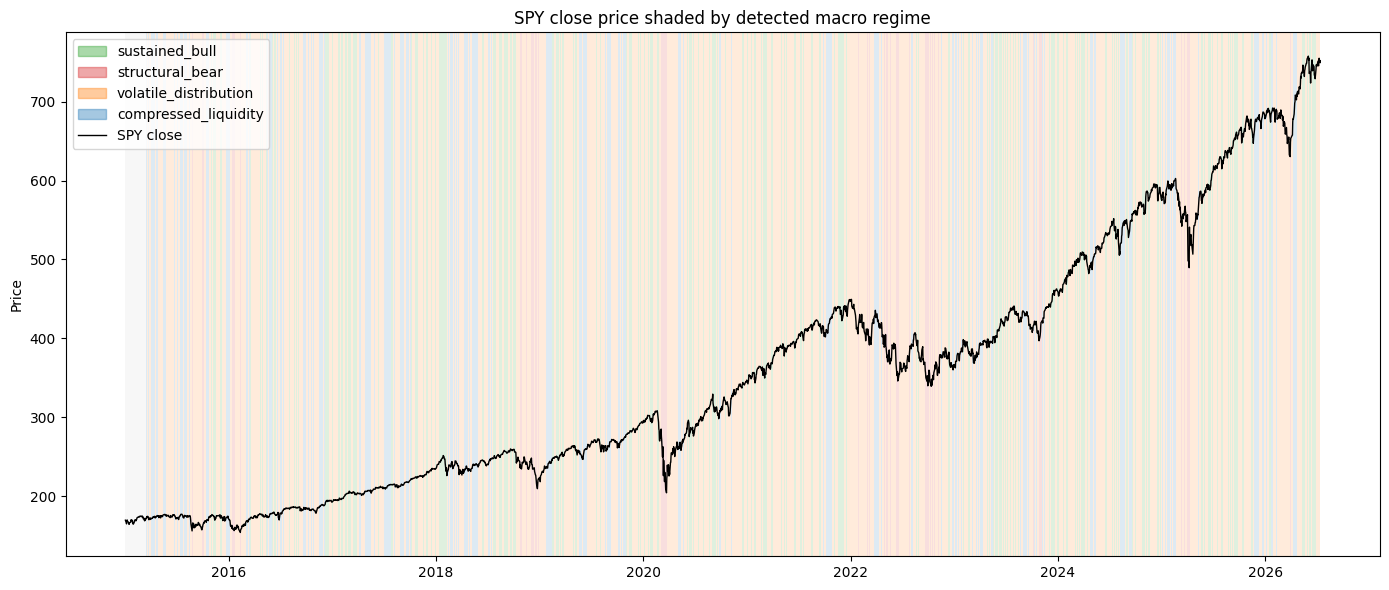

In [4]:
REGIME_COLORS = {
    "sustained_bull": "#2ca02c",
    "structural_bear": "#d62728",
    "volatile_distribution": "#ff7f0e",
    "compressed_liquidity": "#1f77b4",
}

fig, ax = plt.subplots(figsize=(14, 6))

# Shade contiguous regime segments as background bands.
regime_values = regimes.fillna("unclassified")
segment_start = 0
for i in range(1, len(regime_values) + 1):
    if i == len(regime_values) or regime_values.iloc[i] != regime_values.iloc[segment_start]:
        label = regime_values.iloc[segment_start]
        color = REGIME_COLORS.get(label, "#cccccc")
        ax.axvspan(
            ohlcv.index[segment_start],
            ohlcv.index[min(i, len(regime_values) - 1)],
            color=color,
            alpha=0.15,
            linewidth=0,
        )
        segment_start = i

ax.plot(ohlcv.index, ohlcv["close"], color="black", linewidth=1.0, label=f"{TICKER} close")

handles = [plt.Rectangle((0, 0), 1, 1, color=c, alpha=0.4) for c in REGIME_COLORS.values()]
ax.legend(handles + ax.get_lines(), list(REGIME_COLORS.keys()) + [f"{TICKER} close"], loc="upper left")
ax.set_title(f"{TICKER} close price shaded by detected macro regime")
ax.set_ylabel("Price")
plt.tight_layout()
plt.show()

## 3. Run the full-sample backtest

`run_backtest` wires the regime engine into `StrategyManager` (signal generation), `RiskManager` (position sizing / circuit breakers / stops), and `MockBroker` (paper execution with slippage) to produce an equity curve, the regime series, and a full fill ledger.

In [5]:
result = run_backtest(ohlcv, settings)

metrics = compute_metrics(result.equity_curve)
print(f"Strategy metrics over full sample ({TICKER}, {START} to present):")
for key, value in metrics.items():
    print(f"  {key:>15}: {value:.4f}")

Strategy metrics over full sample (SPY, 2015-01-01 to present):
     total_return: -0.0290
     sharpe_ratio: -0.3612
     max_drawdown: -0.0359
         win_rate: 0.0166


## 4. Compare against benchmarks

We compute two simple reference strategies over the same data:

- **Buy & hold**: fully invested from day one, no rebalancing.
- **DMA crossover**: long when price is above its trailing simple moving average, flat otherwise.

Plotting all three equity curves together shows how the regime-adaptive strategy behaves relative to a passive baseline and a simple trend-following rule.

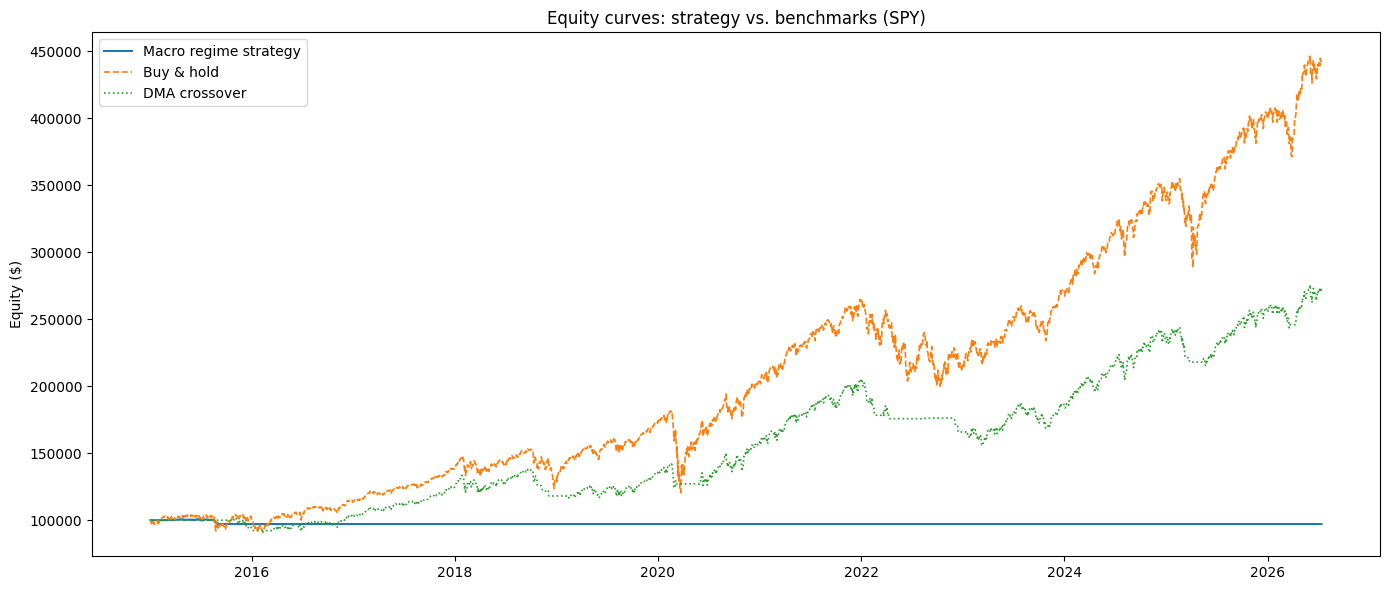

In [6]:
bh_equity = buy_and_hold_equity(ohlcv, settings)
dma_equity = dma_crossover_equity(ohlcv, settings)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(result.equity_curve.index, result.equity_curve, label="Macro regime strategy", linewidth=1.5)
ax.plot(bh_equity.index, bh_equity, label="Buy & hold", linewidth=1.2, linestyle="--")
ax.plot(dma_equity.index, dma_equity, label="DMA crossover", linewidth=1.2, linestyle=":")
ax.set_title(f"Equity curves: strategy vs. benchmarks ({TICKER})")
ax.set_ylabel("Equity ($)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

In [7]:
comparison = pd.DataFrame(
    {
        "macro_regime_strategy": compute_metrics(result.equity_curve),
        "buy_and_hold": compute_metrics(bh_equity),
        "dma_crossover": compute_metrics(dma_equity),
    }
).T
comparison

,total_return,sharpe_ratio,max_drawdown,win_rate
macro_regime_strategy,-0.028956,-0.361166,-0.035911,0.016569
buy_and_hold,3.430665,0.822925,-0.337173,0.547808
dma_crossover,1.725776,0.817701,-0.240623,0.436659


## 5. Inspect the trade ledger

`MockBroker` records a `Fill` for every bar (including no-op `hold` bars where exposure did not change materially). Here are the last 15 entries of the simulation ledger, showing side, quantity, fill price, slippage cost, and resulting equity.

In [8]:
result.ledger.tail(15)

,timestamp,side,quantity,price,slippage_cost,equity_after
2883,2026-06-23,hold,0.0,733.580017,0.0,97104.37615
2884,2026-06-24,hold,0.0,733.239990,0.0,97104.37615
2885,2026-06-25,hold,0.0,734.299988,0.0,97104.37615
2886,2026-06-26,hold,0.0,728.989990,0.0,97104.37615
2887,2026-06-29,hold,0.0,741.000000,0.0,97104.37615
2888,2026-06-30,hold,0.0,746.770020,0.0,97104.37615
2889,2026-07-01,hold,0.0,745.760010,0.0,97104.37615
2890,2026-07-02,hold,0.0,744.780029,0.0,97104.37615
2891,2026-07-06,hold,0.0,751.280029,0.0,97104.37615
2892,2026-07-07,hold,0.0,747.710022,0.0,97104.37615


## 6. Walk-forward (out-of-sample) evaluation

The full-sample backtest above lets every bar's regime classification warm up on *all* prior history at once, which is realistic for live trading (you always have your full history available) but can make performance look smoother than it would if the strategy's indicators had only ever seen a rolling training window.

`run_walk_forward_backtest` instead splits history into repeated `(train_window, test_window)` blocks: each block re-warms the regime engine/indicators on its own `train_window` of history, then reports results only for the following `test_window` - the true out-of-sample segment. Stitching together only the OOS segments across all windows gives a more conservative, lookahead-free view of how the strategy performs on data its indicators were not already primed with.

Walk-forward produced 45 out-of-sample windows covering 2700 bars.
Out-of-sample (walk-forward) metrics:
     total_return: 0.0017
     sharpe_ratio: 0.0474
     max_drawdown: -0.1428
         win_rate: 0.3435


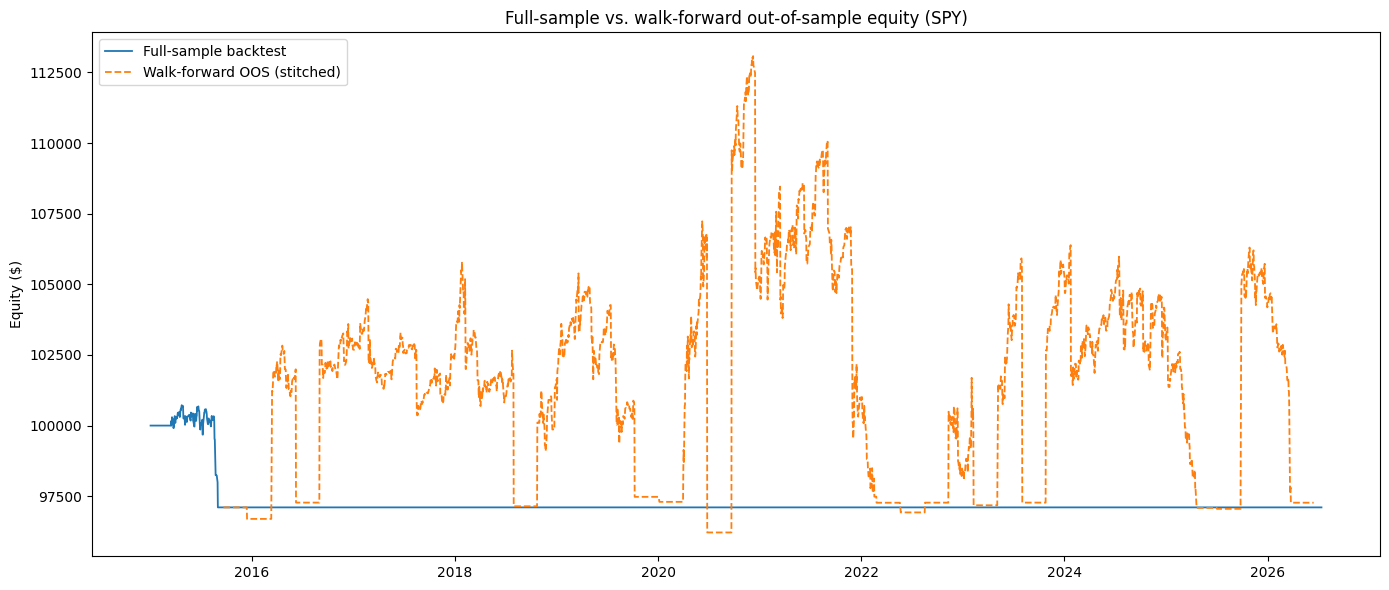

In [9]:
wf_results = run_walk_forward_backtest(ohlcv, settings)

oos_equity = pd.concat([r.equity_curve for r in wf_results]).sort_index()
oos_metrics = compute_metrics(oos_equity)

print(f"Walk-forward produced {len(wf_results)} out-of-sample windows covering {len(oos_equity)} bars.")
print("Out-of-sample (walk-forward) metrics:")
for key, value in oos_metrics.items():
    print(f"  {key:>15}: {value:.4f}")

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(result.equity_curve.index, result.equity_curve, label="Full-sample backtest", linewidth=1.3)
ax.plot(oos_equity.index, oos_equity, label="Walk-forward OOS (stitched)", linewidth=1.3, linestyle="--")
ax.set_title(f"Full-sample vs. walk-forward out-of-sample equity ({TICKER})")
ax.set_ylabel("Equity ($)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## Closing notes

Everything above is a **simulation**: `MockBroker` is a paper-trading engine with synthetic slippage, and no real broker connection or API keys are used anywhere in this notebook.

The same workflow is available outside of a notebook:

- `mrt backtest --ticker SPY` runs an equivalent full-sample (or `--walk-forward`) backtest from the command line.
- `mrt dashboard` launches an interactive dashboard equivalent of the charts shown here.

See `macro_regime_trader.cli` for the full set of CLI options.